In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [76]:
data = pd.read_csv('../dataset/dataset_kematangan_tapai.csv')

In [77]:
input_columns = ['jam', 'suhu', 'kelembaban', 'kadar_gas']
output_columns = ['status_kematangan']

label_encoder = LabelEncoder()
scaler = StandardScaler()

data['status_kematangan'] = label_encoder.fit_transform(data['status_kematangan'])
data.head()

,percobaan,jam,suhu,kelembaban,kadar_gas,status_kematangan
0,1,1,28.73,78.77,0.02,0
1,1,2,28.51,78.62,0.01,0
2,1,3,28.33,78.22,0.01,0
3,1,4,29.20,78.46,0.01,0
4,1,5,28.42,78.65,0.00,0


In [78]:
data_scaled = data.copy()
data_scaled[input_columns] = scaler.fit_transform(data[input_columns])

SEQUENCE_LENGTH = 3
n_features = len(input_columns)

X_sequences = []
y_labels = []

for percobaan_id, group in data_scaled.groupby('percobaan'):
    group = group.reset_index(drop=True)
    features = group[input_columns].values
    targets = group['status_kematangan'].values

    for i in range(len(group)):
        seq = np.zeros((SEQUENCE_LENGTH, n_features))

        for s in range(SEQUENCE_LENGTH):
            idx = i - (SEQUENCE_LENGTH - 1 - s)
            if idx >= 0:
                seq[s] = features[idx]

        X_sequences.append(seq)
        y_labels.append(targets[i])

X = np.array(X_sequences)
y = np.array(y_labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Classes: {label_encoder.classes_}")

X shape: (600, 3, 4)
y shape: (600,)
Classes: ['belum matang' 'matang' 'terlalu matang']


In [79]:
n_classes = len(label_encoder.classes_)
y_cat = to_categorical(y, num_classes=n_classes)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.33, random_state=0, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (402, 3, 4), Test: (198, 3, 4)


In [80]:
model = Sequential([
    LSTM(64, input_shape=(SEQUENCE_LENGTH, n_features), return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/Users/vitoramadhan/izzaalfiansyah/learning/shabrinas-journal/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 3, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,179 (117.89 KB)

 Trainable params: 30,179 (117.89 KB)

 Non-trainable params: 0 (0.00 B)

In [81]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6542 - loss: 1.0520 - val_accuracy: 0.8642 - val_loss: 0.9506
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8411 - loss: 0.8761 - val_accuracy: 0.8519 - val_loss: 0.7601
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8442 - loss: 0.6748 - val_accuracy: 0.8642 - val_loss: 0.5547
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8411 - loss: 0.4905 - val_accuracy: 0.8642 - val_loss: 0.4043
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8505 - loss: 0.3838 - val_accuracy: 0.8642 - val_loss: 0.3310
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8629 - loss: 0.3284 - val_accuracy: 0.8889 - val_loss: 0.2852
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8692 - loss: 0.2972 - val_accuracy: 0.9012 - val_loss: 0.2533
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8723 - loss: 0.2697 - val_accuracy: 0.9012 - 

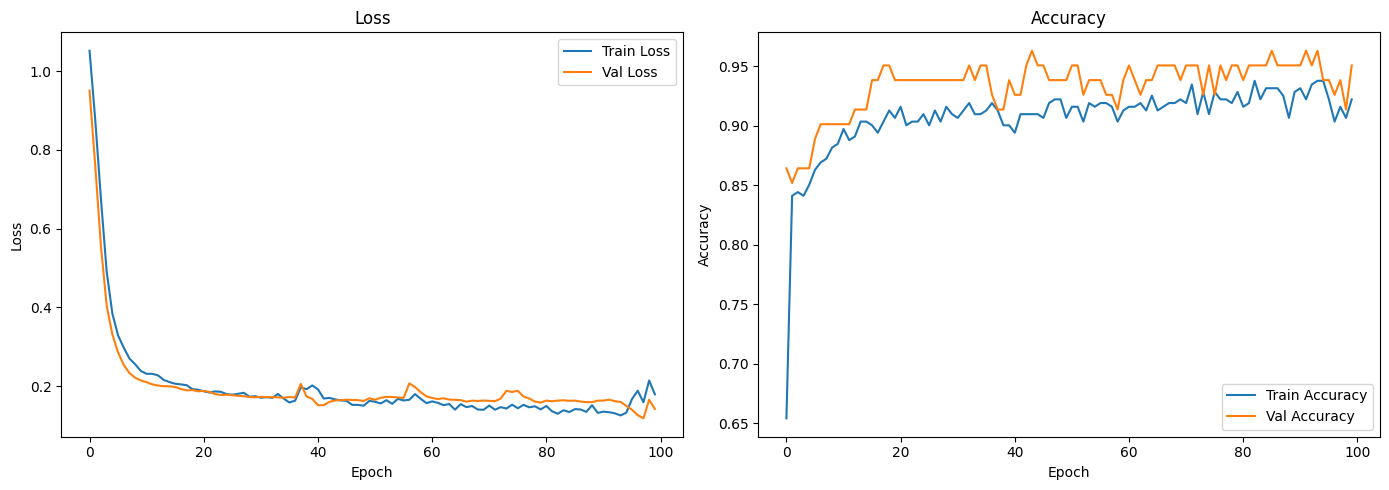

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

In [83]:
y_pred_prob = model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

acc_score = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
class_report = classification_report(y_true, y_pred, target_names=label_encoder.classes_)

print(f"Accuracy Score: {acc_score}")
print(f"F1 Score: {f1}")
print(class_report)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Accuracy Score: 0.9646464646464646
F1 Score: 0.9324656361577514
                precision    recall  f1-score   support

  belum matang       1.00      0.97      0.99       138
        matang       0.80      0.91      0.85        22
terlalu matang       0.95      0.97      0.96        38

      accuracy                           0.96       198
     macro avg       0.92      0.95      0.93       198
  weighted avg       0.97      0.96      0.97       198

